# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

## Project Objective

The objective of this project is to analyze customer and marketing campaign data to understand the factors influencing term deposit subscriptions.

The analysis focuses on:

- Understanding customer demographics and behavior
- Evaluating marketing campaign effectiveness
- Identifying customer segments with higher subscription rates
- Discovering important factors associated with term deposit subscription
- Building machine learning models to predict customer subscription
- Providing actionable recommendations for improving future marketing campaigns

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Display settings
pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

In [3]:



# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()

#Basic Dataset Inspection
print("Dataset Shape:", df.shape)
df.info()
df.tail()
df.columns.tolist()
df.dtypes

Dataset Shape: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx  

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [4]:

# Check for missing values and data types
# Missing values
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

missing_percentage

#Duplicate analysis
print("Number of duplicate rows:", df.duplicated().sum())
df[df.duplicated()].head()

Number of duplicate rows: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [5]:

# Summary statistics
df.describe()
df.describe(include='object')
df.describe(include='all').T

#Identify Categorical Columns
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_34088\2262314969.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')
C:\Users\Admin\AppData\Local\Temp\ipykernel_34088\2262314969.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

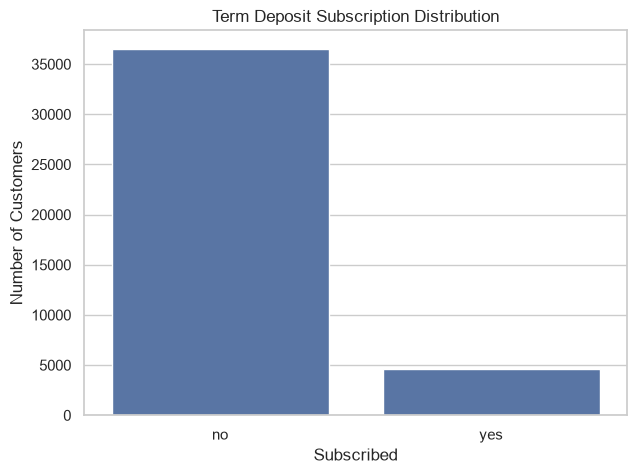

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [6]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
df.columns
df['y'].value_counts()
df['y'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='y')

plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscribed')
plt.ylabel('Number of Customers')

plt.show()
subscription_rate = df['y'].value_counts(normalize=True) * 100

subscription_rate



In [7]:
#first KPI
total_customers = len(df)

subscribed_customers = (df['y'] == 'yes').sum()

subscription_rate = subscribed_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Subscribed Customers:", subscribed_customers)
print(f"Subscription Rate: {subscription_rate:.2f}%")

Total Customers: 41188
Subscribed Customers: 4640
Subscription Rate: 11.27%


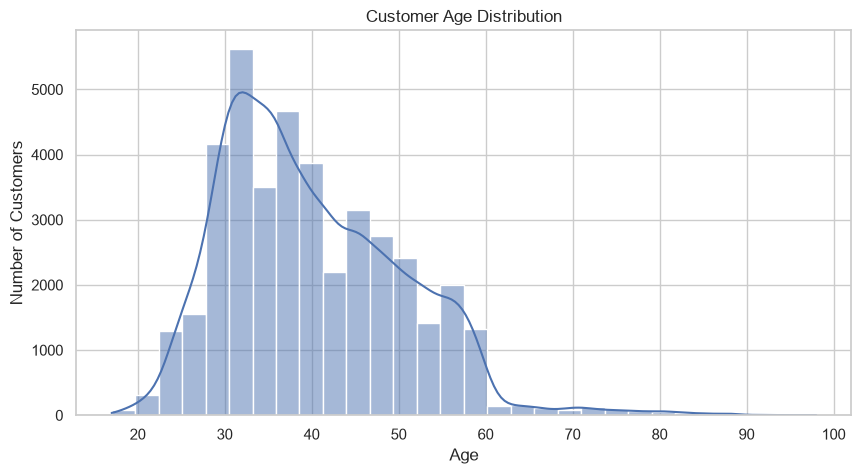

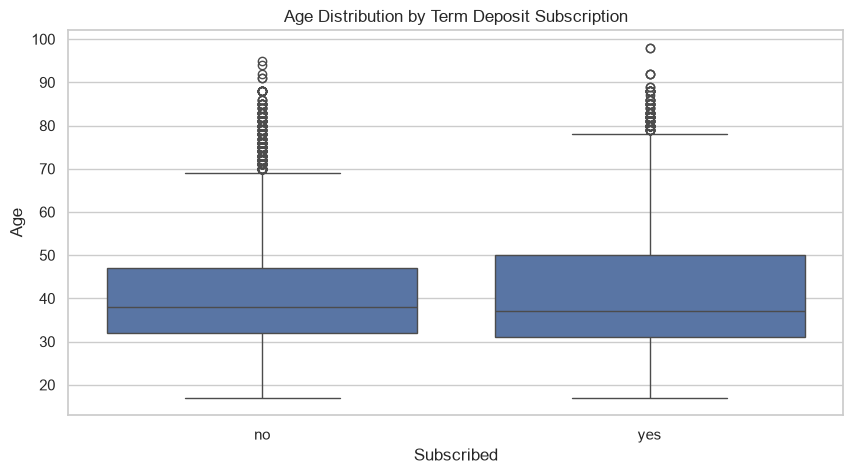

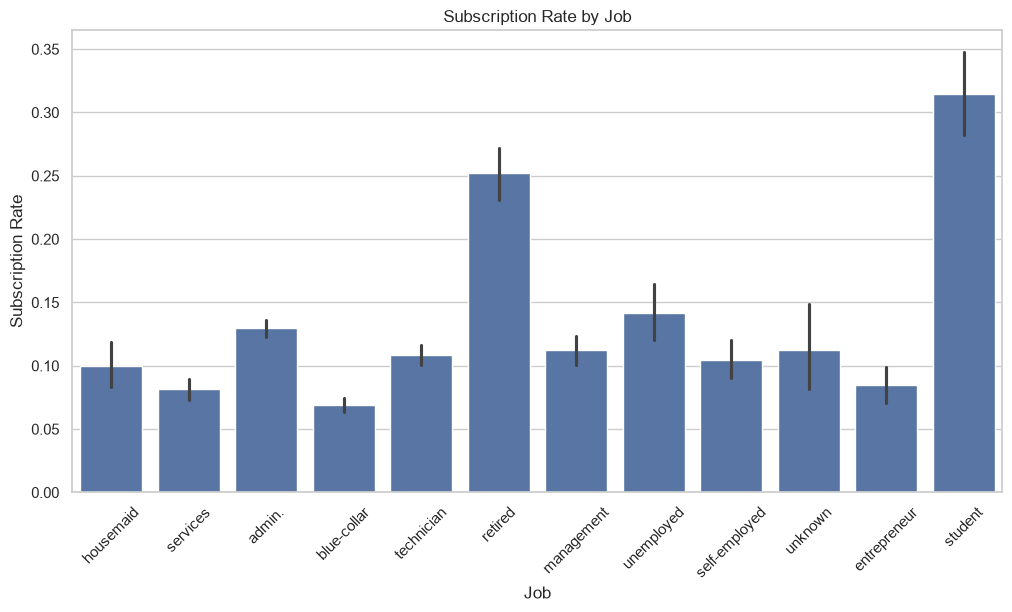

In [11]:
#Age Analysis
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x='y', y='age')

plt.title('Age Distribution by Term Deposit Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Age')

plt.show()

#Job Analysis
job_subscription = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_subscription

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x='job',
    y=(df['y'] == 'yes').astype(int)
)

plt.xticks(rotation=45)
plt.title('Subscription Rate by Job')
plt.xlabel('Job')
plt.ylabel('Subscription Rate')

plt.show()

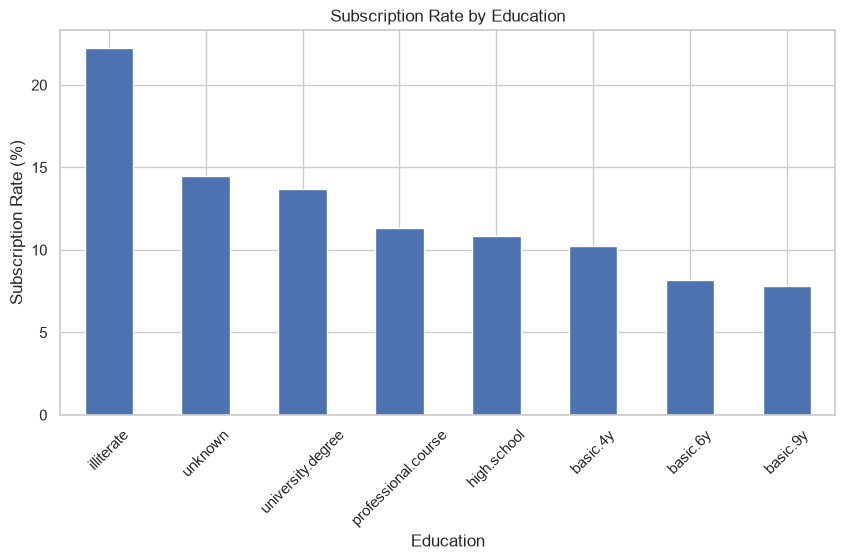

In [12]:
#Education Analysis
education_rate = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('education')['subscribed']
      .mean()
      .sort_values(ascending=False)
      * 100
)

education_rate
plt.figure(figsize=(10, 5))

education_rate.plot(kind='bar')

plt.title('Subscription Rate by Education')
plt.xlabel('Education')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=45)

plt.show()

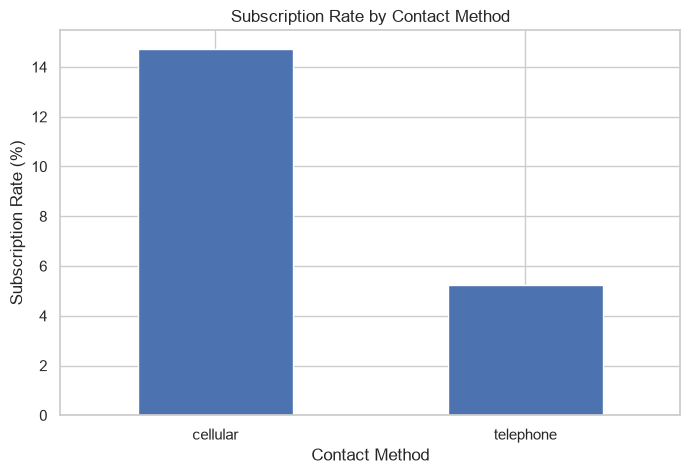

In [13]:
#Contact Analysis
contact_rate = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('contact')['subscribed']
      .mean()
      .sort_values(ascending=False)
      * 100
)

contact_rate

plt.figure(figsize=(8, 5))

contact_rate.plot(kind='bar')

plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

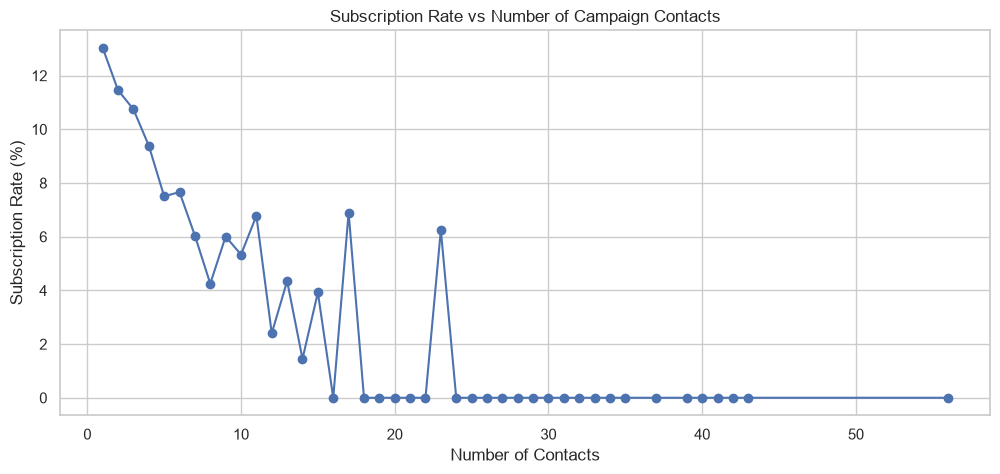

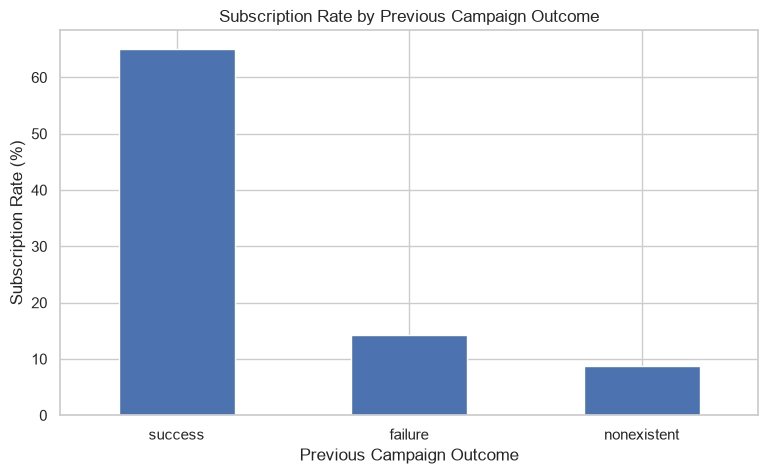

In [15]:
#Campaign Analysis
campaign_rate = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('campaign')['subscribed']
      .mean()
      .sort_index()
      * 100
)

campaign_rate.head(15)
plt.figure(figsize=(12, 5))

campaign_rate.plot(kind='line', marker='o')

plt.title('Subscription Rate vs Number of Campaign Contacts')
plt.xlabel('Number of Contacts')
plt.ylabel('Subscription Rate (%)')

plt.show()

#Previous Campaign Analysis
poutcome_rate = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('poutcome')['subscribed']
      .mean()
      .sort_values(ascending=False)
      * 100
)

poutcome_rate
plt.figure(figsize=(9, 5))

poutcome_rate.plot(kind='bar')

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

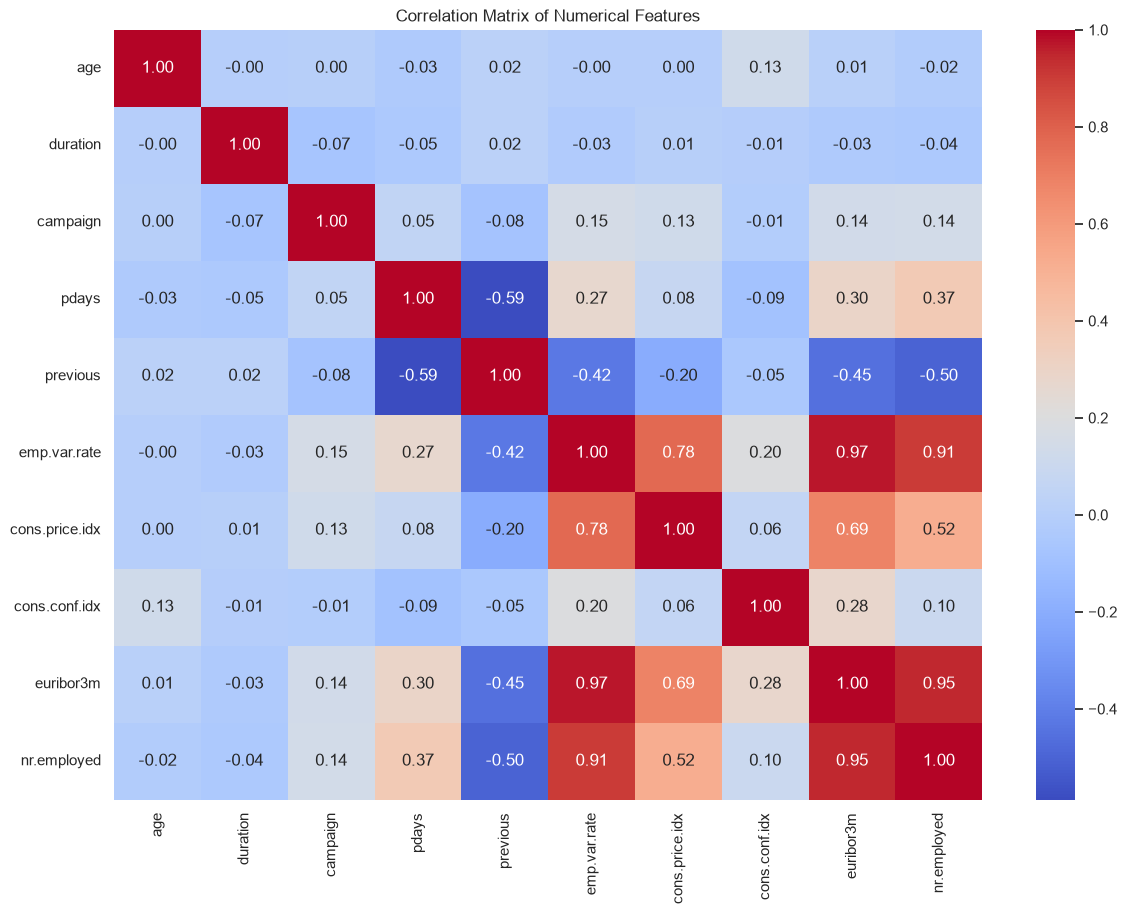

In [16]:

# Correlation matrix for numerical features
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()


## Customer Demographic Analysis

Understanding customer demographics helps identify which customer groups are more likely to subscribe to a term deposit.

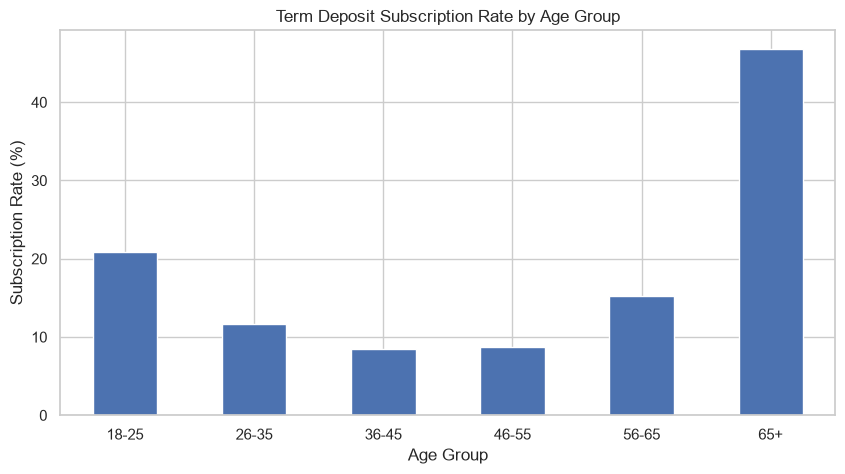

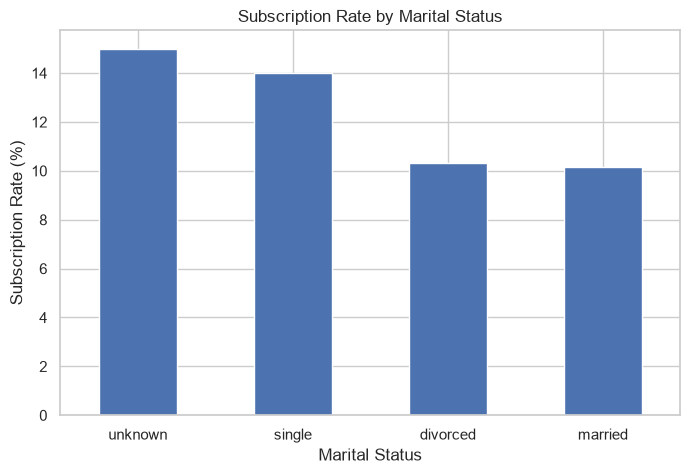

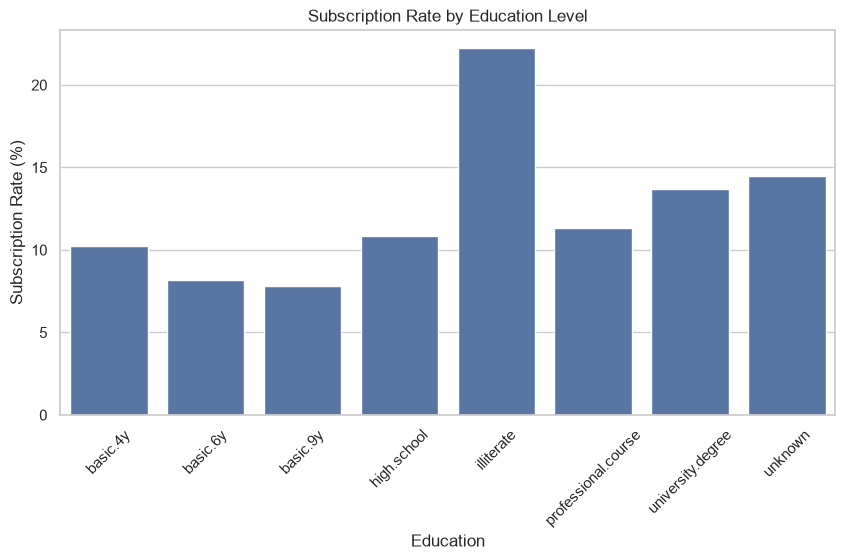

In [19]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

df['age_group'].value_counts().sort_index()

age_subscription = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('age_group', observed=True)['subscribed']
      .mean()
      .mul(100)
)

age_subscription

plt.figure(figsize=(10, 5))

age_subscription.plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

#Marital Status Analysis
marital_subscription = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('marital')['subscribed']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

marital_subscription
plt.figure(figsize=(8, 5))

marital_subscription.plot(kind='bar')

plt.title('Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

#Education Analysis
education_analysis = (
    df.groupby('education')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

education_analysis['subscription_rate'] = (
    education_analysis['subscribed']
    / education_analysis['customers']
    * 100
)

education_analysis.sort_values(
    'subscription_rate',
    ascending=False
)
plt.figure(figsize=(10, 5))

sns.barplot(
    x=education_analysis.index,
    y=education_analysis['subscription_rate']
)

plt.title('Subscription Rate by Education Level')
plt.xlabel('Education')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=45)

plt.show()


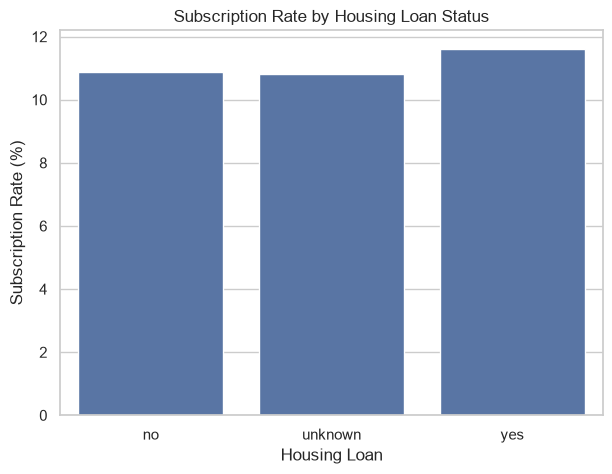

In [20]:
#Financial & Loan Analysis
#Housing Loan
housing_analysis = (
    df.groupby('housing')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

housing_analysis['subscription_rate'] = (
    housing_analysis['subscribed']
    / housing_analysis['customers']
    * 100
)

housing_analysis
plt.figure(figsize=(7, 5))

sns.barplot(
    x=housing_analysis.index,
    y=housing_analysis['subscription_rate']
)

plt.title('Subscription Rate by Housing Loan Status')
plt.xlabel('Housing Loan')
plt.ylabel('Subscription Rate (%)')

plt.show()

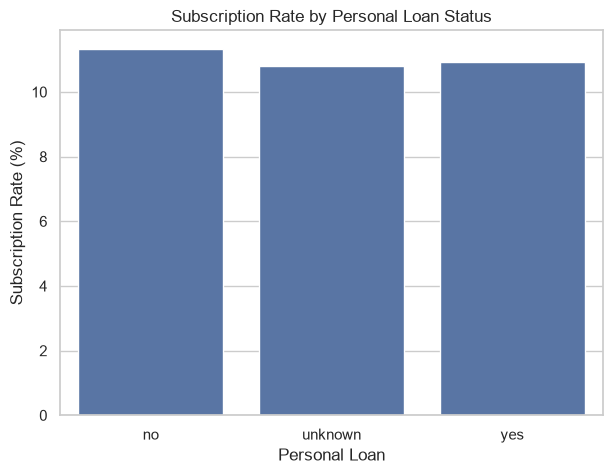

,customers,subscribed,subscription_rate
default,,,
no,32588,4197,12.878974
unknown,8597,443,5.152960
yes,3,0,0.000000


In [21]:
#Personal Loan Analysis
loan_analysis = (
    df.groupby('loan')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

loan_analysis['subscription_rate'] = (
    loan_analysis['subscribed']
    / loan_analysis['customers']
    * 100
)

loan_analysis
plt.figure(figsize=(7, 5))

sns.barplot(
    x=loan_analysis.index,
    y=loan_analysis['subscription_rate']
)

plt.title('Subscription Rate by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Subscription Rate (%)')

plt.show()

#Default Status Analysis
default_analysis = (
    df.groupby('default')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

default_analysis['subscription_rate'] = (
    default_analysis['subscribed']
    / default_analysis['customers']
    * 100
)

default_analysis

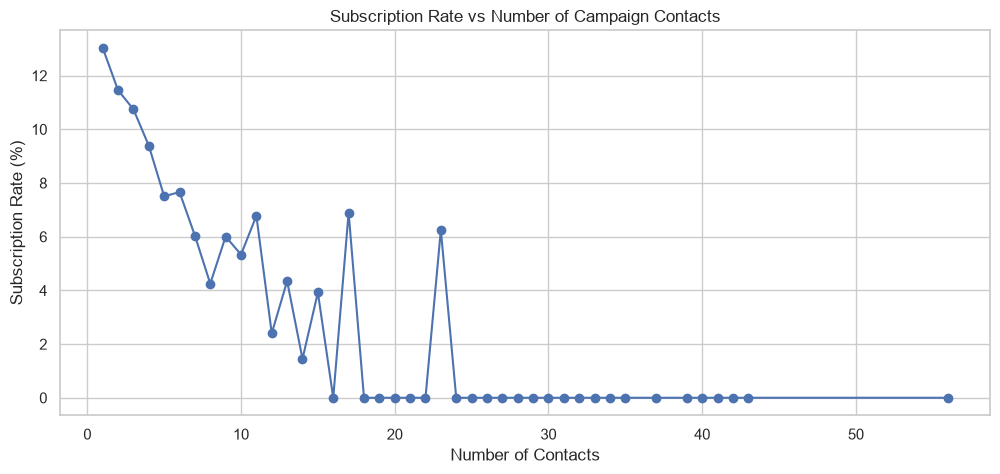

In [22]:
#Marketing Campaign Analysis
contact_analysis = (
    df.groupby('contact')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

contact_analysis['subscription_rate'] = (
    contact_analysis['subscribed']
    / contact_analysis['customers']
    * 100
)

contact_analysis.sort_values(
    'subscription_rate',
    ascending=False
)

#Number of Contacts
campaign_analysis = (
    df.groupby('campaign')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

campaign_analysis['subscription_rate'] = (
    campaign_analysis['subscribed']
    / campaign_analysis['customers']
    * 100
)

campaign_analysis.head(15)
plt.figure(figsize=(12, 5))

plt.plot(
    campaign_analysis.index,
    campaign_analysis['subscription_rate'],
    marker='o'
)

plt.title('Subscription Rate vs Number of Campaign Contacts')
plt.xlabel('Number of Contacts')
plt.ylabel('Subscription Rate (%)')

plt.show()

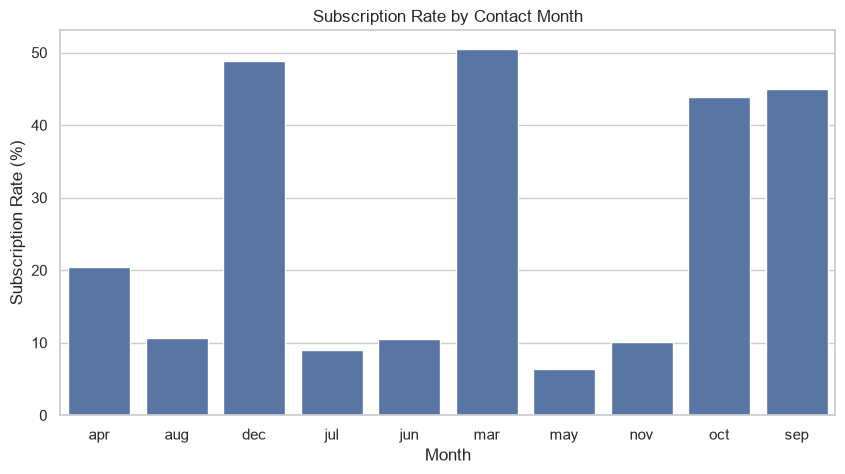

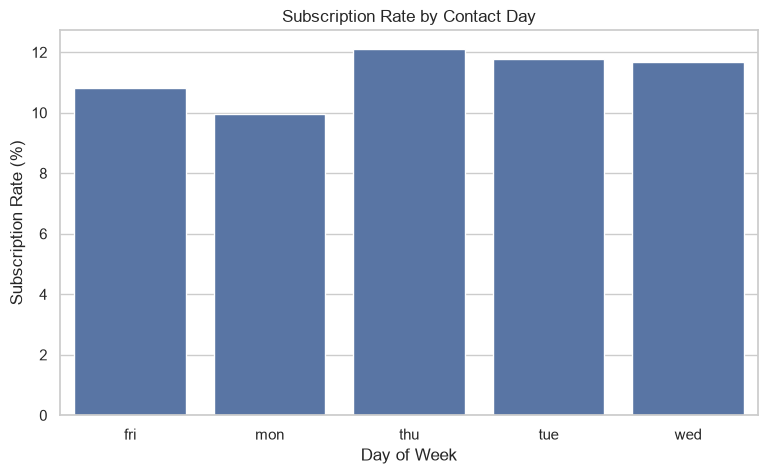

In [23]:
#Month Analysis
month_analysis = (
    df.groupby('month')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

month_analysis['subscription_rate'] = (
    month_analysis['subscribed']
    / month_analysis['customers']
    * 100
)

month_analysis
plt.figure(figsize=(10, 5))

sns.barplot(
    x=month_analysis.index,
    y=month_analysis['subscription_rate']
)

plt.title('Subscription Rate by Contact Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate (%)')

plt.show()

#Day of Week Analysis
day_analysis = (
    df.groupby('day_of_week')
      .agg(
          customers=('y', 'size'),
          subscribed=('y', lambda x: (x == 'yes').sum())
      )
)

day_analysis['subscription_rate'] = (
    day_analysis['subscribed']
    / day_analysis['customers']
    * 100
)

day_analysis
plt.figure(figsize=(9, 5))

sns.barplot(
    x=day_analysis.index,
    y=day_analysis['subscription_rate']
)

plt.title('Subscription Rate by Contact Day')
plt.xlabel('Day of Week')
plt.ylabel('Subscription Rate (%)')

plt.show()

In [24]:
#Customer Segmentation
job_education = pd.crosstab(
    [df['job'], df['education']],
    df['y'],
    normalize='index'
) * 100

job_education

#Create a Top Customer Segment Table
segment_analysis = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby(['job', 'education'])
      .agg(
          customers=('subscribed', 'size'),
          subscriptions=('subscribed', 'sum'),
          subscription_rate=('subscribed', 'mean')
      )
)

segment_analysis['subscription_rate'] *= 100

segment_analysis = segment_analysis[
    segment_analysis['customers'] >= 50
].sort_values(
    'subscription_rate',
    ascending=False
)

segment_analysis.head(10)

customers  subscriptions  subscription_rate
job       education                                                       
student   basic.9y                    99             35          35.353535
          unknown                    167             59          35.329341
retired   unknown                     98             33          33.673469
student   high.school                357            114          31.932773
retired   basic.4y                   597            185          30.988275
          professional.course        241             57          23.651452
          university.degree          285             66          23.157895
          high.school                276             62          22.463768
student   university.degree          170             35          20.588235
housemaid professional.course         59             11          18.644068

## Key Business Insights

### Customer Demographics
- Analyze which age groups show the highest subscription rates.
- Identify the job and education groups with stronger subscription performance.
- Compare subscription behavior across marital-status categories.

### Loan and Financial Behavior
- Examine whether customers with housing or personal loans differ in subscription behavior.
- Evaluate the relationship between financial indicators and subscription outcomes.

### Marketing Campaign Performance
- Compare subscription rates across contact methods.
- Analyze the effect of campaign contact frequency.
- Evaluate previous campaign outcomes.
- Identify months and days with stronger campaign performance.

### Customer Segmentation
- Identify customer segments with relatively high subscription rates.
- Use these segments to support targeted marketing strategies.

### Business Recommendation
- Prioritize customer segments with higher historical subscription rates.
- Focus marketing efforts on more effective contact methods.
- Avoid excessive repeated contacts when they show declining conversion.
- Use previous campaign outcomes to improve customer targeting.

## Conclusion

This project provided a comprehensive analysis of customer characteristics and marketing campaign performance using bank marketing data. The analysis covered customer demographics, education, marital status, loan information, contact methods, campaign frequency, call duration, previous campaign outcomes, contact timing, and economic indicators.

The findings show that customer subscription behavior varies across different customer segments and campaign characteristics. This highlights the importance of understanding customer profiles and using data-driven segmentation rather than applying the same marketing strategy to every customer.

The analysis also demonstrates that campaign-related factors such as contact method, contact frequency, call duration, and previous campaign outcomes can provide valuable insights for evaluating marketing effectiveness.

### Key Takeaways

* Customer demographics can support more effective customer segmentation.
* Subscription behavior varies across different customer groups.
* Campaign characteristics provide useful insights into marketing performance.
* Previous campaign outcomes can help inform future customer targeting.
* Data-driven segmentation can help improve marketing efficiency and decision-making.

### Future Scope

The project can be further extended by developing predictive machine learning models and an interactive dashboard to support real-time campaign analysis and customer targeting.
